In [10]:
import numpy as np 
import sunpy
import sunpy.map 
import sunpy.coordinates
from sunpy.map import make_heliographic_header, make_fitswcs_header
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
        LogStretch, LinearStretch, CompositeStretch)
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
from scipy import ndimage

import sys
sys.path.append("/cluster/home/zhuyin/scripts/greensfield/")
import greensfield
from greensfield.util import make_boundary_magnetogram

import skimage.filters

In [2]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_br_warp_to_hmi.fits")
sotsp_bt_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bt_warp_to_hmi.fits")
sotsp_bp_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bp_warp_to_hmi.fits")

# sotsp_br_map = sotsp_br_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)
# sotsp_bt_map = sotsp_bt_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)
# sotsp_bp_map = sotsp_bp_map.submap([300, 100]*u.pix, top_right=[300+410-1, 100+400-1]*u.pix)


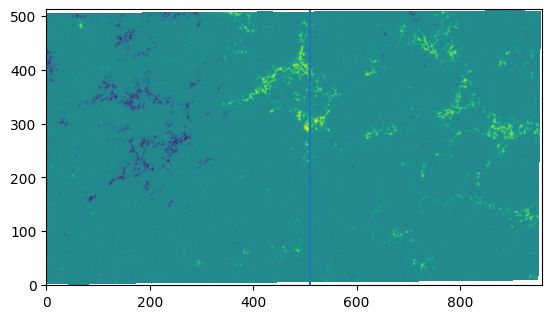

In [6]:
fig, ax = plt.subplots()
ax.imshow(sotsp_br_map.data, origin="lower",
          aspect=sotsp_br_map.scale.axis2/sotsp_br_map.scale.axis1,
          )
ax.axvline(510)

In [11]:
roi_frac = (sotsp_br_map.data.shape[1] - 510)/sotsp_br_map.data.shape[1]
print(roi_frac)

0.4681960375391032


In [12]:
t_start = Time("2022-10-24T18:41:38")
t_end = Time("2022-10-24T19:44:50")
print(t_start + (t_end - t_start)*roi_frac)

2022-10-24T19:11:13.399


In [3]:
sotsp_map_bottom_left_hgs = sotsp_bp_map.bottom_left_coord.transform_to("heliographic_stonyhurst")
sotsp_map_center_hgs = sotsp_bp_map.center.transform_to("heliographic_stonyhurst")
sotsp_map_top_right_hgs = sotsp_bp_map.top_right_coord.transform_to("heliographic_stonyhurst")

In [4]:
scale_hgs = (sotsp_map_top_right_hgs.lon - sotsp_map_bottom_left_hgs.lon)/sotsp_bp_map.data.shape[1]/u.pix
nx_hgs = np.round(((sotsp_map_top_right_hgs.lon - sotsp_map_bottom_left_hgs.lon)/scale_hgs).to_value(u.pix)).astype(int)
ny_hgs = np.round(((sotsp_map_top_right_hgs.lat - sotsp_map_bottom_left_hgs.lat)/scale_hgs).to_value(u.pix)).astype(int)

if nx_hgs%2 != 0:
    nx_hgs += 1

if ny_hgs%2 != 0:
    ny_hgs += 1

In [5]:
hgs_header_0 = make_fitswcs_header(
    data=(ny_hgs, nx_hgs),
    coordinate=sotsp_map_center_hgs,
    scale=u.Quantity([scale_hgs, scale_hgs]),
    projection_code="CEA")
hgs_wcs_0 = WCS(hgs_header_0)

In [6]:
hgs_header_0

MetaDict([('wcsaxes': '2')
('crpix1': '480.5')
('crpix2': '270.5')
('cdelt1': '0.01952903395272644')
('cdelt2': '0.01952903395272644')
('cunit1': 'deg')
('cunit2': 'deg')
('ctype1': 'HGLN-CEA')
('ctype2': 'HGLT-CEA')
('crval1': '-25.383298675842184')
('crval2': '15.665885774326075')
('lonpole': '0.0')
('latpole': '90.0')
('mjdref': '0.0')
('date-obs': '2022-10-24T18:41:38.918')
('rsun_ref': '696000000.0')
('naxis': '2')
('naxis1': '960')
('naxis2': '540')
('pc1_1': '1.0')
('pc1_2': '-0.0')
('pc2_1': '0.0')
('pc2_2': '1.0')])

In [7]:
sotsp_br_map_hgs_0 = sotsp_br_map.reproject_to(hgs_wcs_0)

In [8]:
sotsp_br_map_hgs_0.save("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits", overwrite=True)

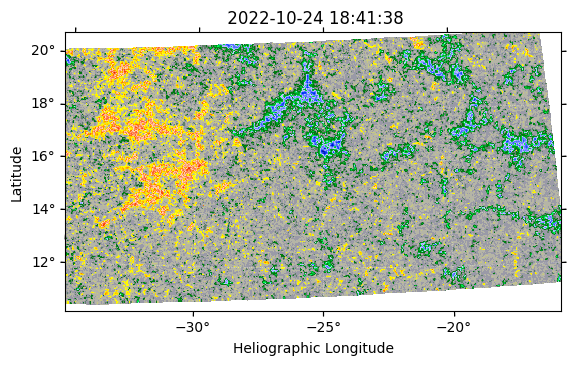

In [9]:
sotsp_br_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag")  

In [10]:
sotsp_br_map_hgs_0.scale.axis1.to_value(u.rad/u.pix)*695.7*hgs_header_0["naxis1"], sotsp_br_map_hgs_0.scale.axis1.to_value(u.rad/u.pix)*695.7

(227.64146111489663, 0.23712652199468398)

In [11]:
sotsp_bp_map_hgs_0 = sotsp_bp_map.reproject_to(hgs_wcs_0)
sotsp_bt_map_hgs_0 = sotsp_bt_map.reproject_to(hgs_wcs_0)

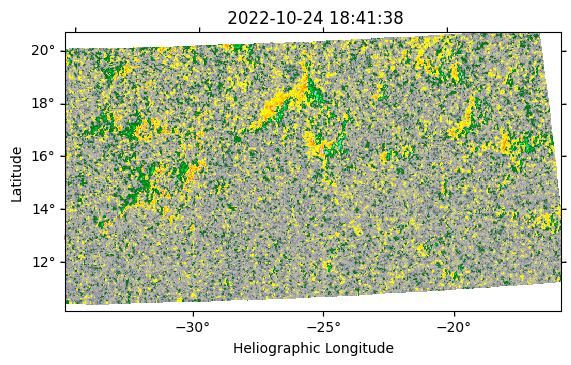

In [12]:
sotsp_bp_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag", interpolation="none")  

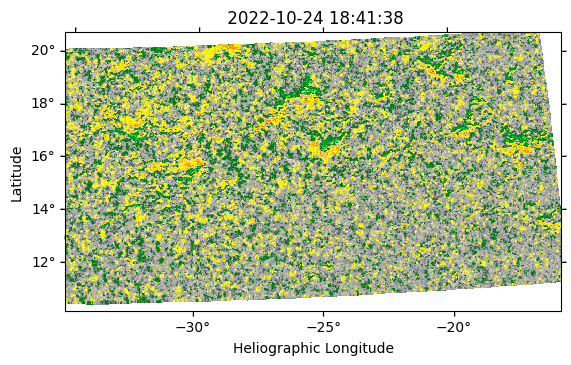

In [13]:
sotsp_bt_map_hgs_0.plot(norm=ImageNormalize(vmin=-1500,vmax=1500),
                       cmap="hmimag", interpolation="none")  

In [14]:
nx_rebin = nx_hgs
ny_rebin = ny_hgs
x = np.linspace(0, nx_rebin-1, nx_rebin)/nx_rebin
y = np.linspace(0, ny_rebin-1, ny_rebin)/nx_rebin

bx = sotsp_bp_map_hgs_0.data.T
# bx = np.nanmean(bx.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))
by = sotsp_bt_map_hgs_0.data.T
# by = np.nanmean(by.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))
bz = sotsp_br_map_hgs_0.data.T
# bz = np.nanmean(bz.reshape(nx_rebin, 4, ny_rebin, 4), axis=(1,3))

bx_smooth = skimage.filters.gaussian(bx, sigma=5)
by_smooth = skimage.filters.gaussian(by, sigma=5)
bz_smooth = skimage.filters.gaussian(bz, sigma=5)

dxby = np.gradient(by_smooth, x, axis=0)
dybx = np.gradient(bx_smooth, y, axis=1)

jz = dxby - dybx
alpha = jz/bz_smooth
alpha[np.abs(bz) < 100] = 0
alpha[np.abs(alpha) > 50] = 0

alpha[~np.isfinite(alpha)] = 0
bz[~np.isfinite(bz)] = 0
# alpha = alpha*0 + np.nanmedian(alpha)

sig = 20

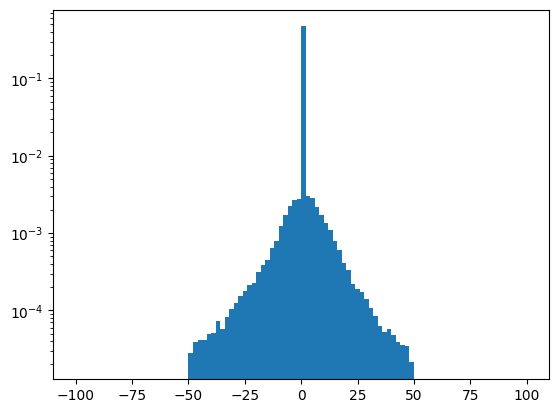

In [15]:
fig, ax = plt.subplots()
_ = ax.hist(alpha.flatten(), bins=100, density=True, range=(-100,100))
ax.set_yscale("log")
# ax.set_xlim(-np.sqrt(2)*np.pi, np.sqrt(2)*np.pi)

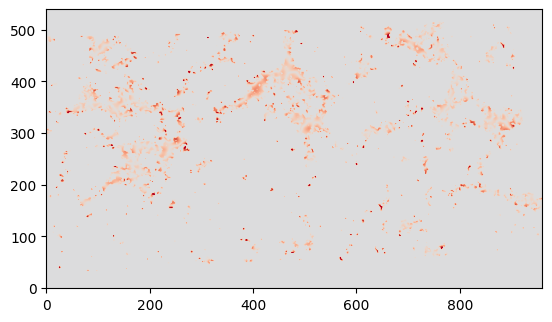

In [16]:
fig, ax = plt.subplots()
ax.imshow(np.abs(alpha.T), origin="lower", 
    norm=ImageNormalize(
    vmin=-30,
    vmax=30),
    cmap="coolwarm")

In [17]:
alpha.shape

(960, 540)

In [18]:
(bz/np.nanmax(np.abs(bz))).astype(np.float64).T.tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP_fullfov/data/bz0.dat")
alpha.astype(np.float64).T.tofile("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP_fullfov/data/alpha0.dat")

In [19]:
np.nansum(alpha)/np.nansum(alpha!=0)/(sotsp_br_map_hgs_0.scale.axis1.to_value(u.rad/u.pix)*695.7*hgs_header_0["naxis1"])

0.004884580737794221

In [20]:
print(np.nanmax(np.abs(bz)))

1370.9076622629343


In [21]:
np.save("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.npy", bz)
np.save("../../data/pid_1_123_aux/SOTSP/sotsp_alpha_hgs_cea_fullfov.npy", alpha)